# Notebook 03 — Exploratory Data Analysis & Hypothesis Testing

**Project:** Customer Review Prediction — Olist Brazilian E-Commerce  

Now that I've got my features engineered, it's time to actually look at the data! Let's see if my gut feelings about what causes bad reviews are actually true.

---

## What I'm Doing Here

### Part A — Visual Exploration (EDA)

I'm going to make a few plots to understand:
- How imbalanced my positive/negative reviews are.
- When people are placing orders.
- How people pay for things.
- What product categories are most popular.
- How often customers come back to buy again.
- Whether shipping costs are making people angry.

### Part B — Statistical Hypothesis Testing

I can't just rely on charts; I need to prove things statistically. I'll run 5 Welch's t-tests to validate my business hypotheses. I'm using Welch's t-test instead of the standard one because it doesn't assume the two groups have equal variance (which they rarely do in the real world!).

For every test, I'll show the p-value and explain exactly what it means for the business.

## 1. Imports and Configuration
Setting up my plotting tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

# ---------------------------------------------------------------------------
# Visual style configuration
# A consistent style throughout the notebook makes it easier to read and
# presents a professional appearance.
# ---------------------------------------------------------------------------
FIGURE_STYLE    = 'seaborn-v0_8-whitegrid'
COLOUR_POSITIVE = '#2196F3'   # Blue for positive reviews
COLOUR_NEGATIVE = '#EF5350'   # Red for negative reviews
COLOUR_PALETTE  = [COLOUR_NEGATIVE, COLOUR_POSITIVE]
FIGURE_DPI      = 120
SIGNIFICANCE_LEVEL = 0.05     # Alpha for hypothesis testing

plt.style.use(FIGURE_STYLE)
plt.rcParams.update({
    'figure.dpi'       : FIGURE_DPI,
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 12,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.titlesize' : 16,
})

pd.set_option('display.float_format', '{:,.4f}'.format)

print('Imports and style configuration complete.')

Imports and style configuration complete.


In [2]:
FEATURE_DATASET_PATH = Path('../data/analytical/feature_dataset.csv')
FIGURES_OUTPUT_DIR   = Path('../outputs/figures')
TABLES_OUTPUT_DIR    = Path('../outputs/tables')

FIGURES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the feature dataset
feature_df = pd.read_csv(FEATURE_DATASET_PATH)

print(f'Feature dataset loaded: {feature_df.shape}')
print(f'\nTarget distribution:')
print(feature_df['positive_review'].value_counts())

Feature dataset loaded: (90540, 25)

Target distribution:
positive_review
1    76045
0    14495
Name: count, dtype: int64


In [3]:
# Separate the dataset into two groups for hypothesis testing.
# This is the foundation for all Welch's t-tests in Part B.

positive_group = feature_df[feature_df['positive_review'] == 1]
negative_group = feature_df[feature_df['positive_review'] == 0]

print(f'Positive review group (score 4-5): {len(positive_group):>7,} orders')
print(f'Negative review group (score 1-2): {len(negative_group):>7,} orders')

Positive review group (score 4-5):  76,045 orders
Negative review group (score 1-2):  14,495 orders


---

# Part A — Exploratory Data Analysis

## Visualization 1 — Review Class Distribution

First, I need to know how unbalanced my target variable is. Do people mostly leave good reviews or bad ones?

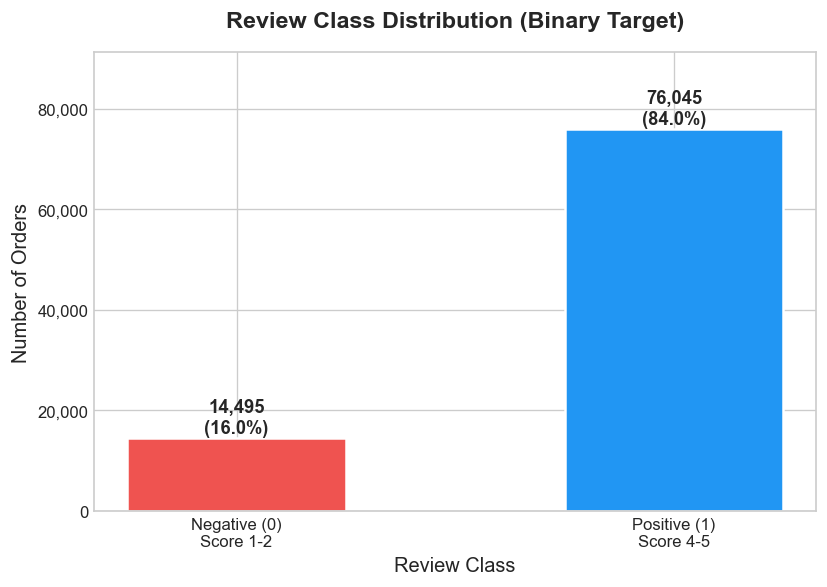

Saved: ..\outputs\figures\viz1_review_class_distribution.png


In [4]:
def plot_review_class_distribution(dataframe: pd.DataFrame,
                                   output_dir: Path) -> None:
    """
    Plot and save a bar chart of the binary review class distribution.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Feature dataset containing the 'positive_review' column.
    output_dir : Path
        Directory where the figure will be saved.
    """
    class_counts = dataframe['positive_review'].value_counts().sort_index()
    class_labels = ['Negative (0)\nScore 1-2', 'Positive (1)\nScore 4-5']
    class_percentages = class_counts / class_counts.sum() * 100

    fig, ax = plt.subplots(figsize=(7, 5))

    bars = ax.bar(
        class_labels,
        class_counts.values,
        color=COLOUR_PALETTE,
        edgecolor='white',
        linewidth=1.5,
        width=0.5
    )

    # Annotate each bar with the count and percentage
    for bar, count, pct in zip(bars, class_counts.values, class_percentages.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

    ax.set_title('Review Class Distribution (Binary Target)', fontweight='bold', pad=15)
    ax.set_ylabel('Number of Orders')
    ax.set_xlabel('Review Class')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylim(0, class_counts.max() * 1.2)

    plt.tight_layout()
    filepath = output_dir / 'viz1_review_class_distribution.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


plot_review_class_distribution(feature_df, FIGURES_OUTPUT_DIR)

### What this means for the project

Wow, it's really skewed. Around 84% of the reviews are positive and only 16% are negative. 

**What this means for my model:** If I build a really dumb model that just guesses "Positive" every single time, it will be 84% accurate! So, accuracy is a terrible metric for this project. I'll need to use Precision, Recall, F1-Score, and ROC-AUC. I'll also need to tell my machine learning model to pay extra attention to the negative class so it actually tries to learn them.

## Visualization 2 — Orders Over Time

Let's see how order volume changed over time. Did they have huge seasonal spikes?

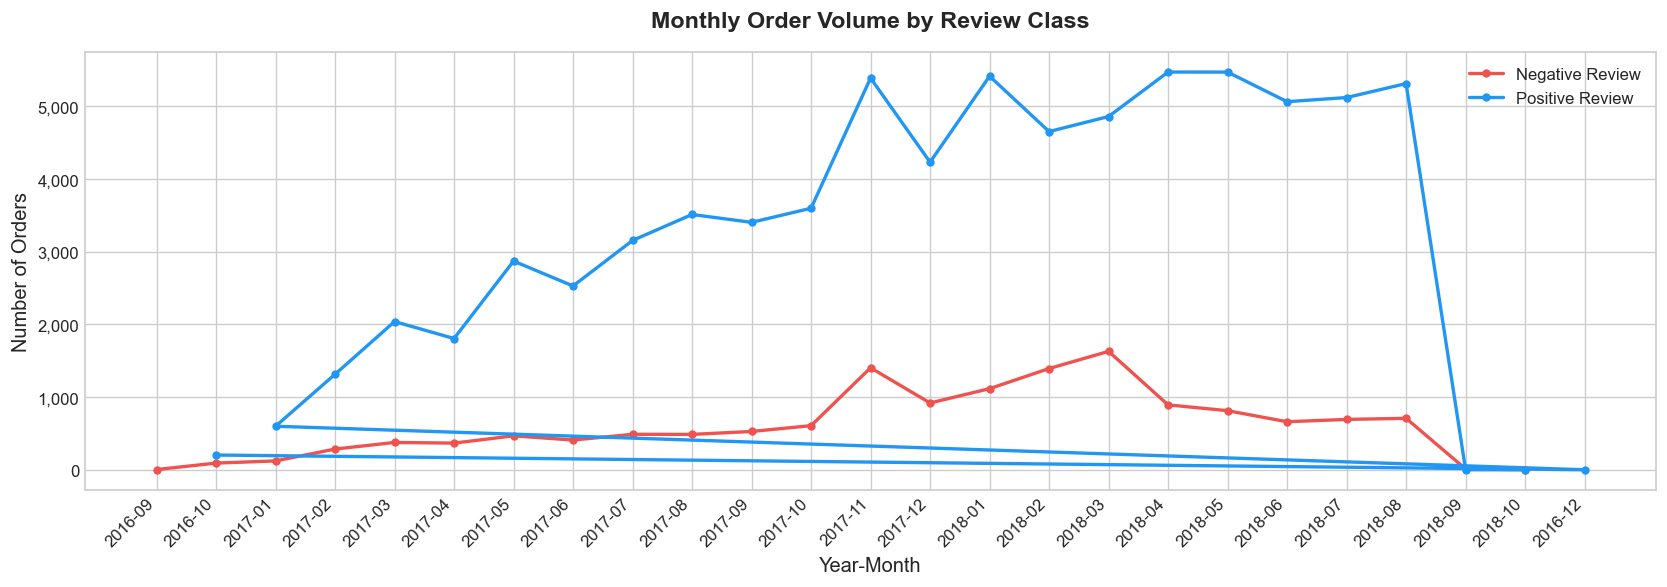

Saved: ..\outputs\figures\viz2_orders_over_time.png


In [5]:
def plot_orders_over_time(dataframe: pd.DataFrame, output_dir: Path) -> None:
    """
    Plot and save a line chart showing the number of orders per month.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Feature dataset; must contain 'purchase_month' and 'positive_review'.
    output_dir : Path
        Directory where the figure will be saved.
    """
    # To create a meaningful time series we need the full date (year+month)
    # Read the analytical dataset for the full purchase timestamp
    analytical_path = Path('../data/analytical/analytical_dataset.csv')
    analytical_temp = pd.read_csv(analytical_path, usecols=['order_id', 'order_purchase_timestamp'])
    analytical_temp['order_purchase_timestamp'] = pd.to_datetime(analytical_temp['order_purchase_timestamp'])
    analytical_temp['year_month'] = analytical_temp['order_purchase_timestamp'].dt.to_period('M')

    # Join to feature_df to get only the orders in our dataset
    merged = dataframe[['order_id', 'positive_review']].merge(
        analytical_temp[['order_id', 'year_month']],
        on='order_id',
        how='left'
    )

    monthly_counts = (
        merged
        .groupby(['year_month', 'positive_review'])
        .size()
        .reset_index(name='order_count')
    )
    monthly_counts['year_month_str'] = monthly_counts['year_month'].astype(str)

    fig, ax = plt.subplots(figsize=(14, 5))

    for review_class, colour, label in [
        (0, COLOUR_NEGATIVE, 'Negative Review'),
        (1, COLOUR_POSITIVE, 'Positive Review')
    ]:
        subset = monthly_counts[monthly_counts['positive_review'] == review_class]
        ax.plot(
            subset['year_month_str'],
            subset['order_count'],
            color=colour,
            linewidth=2,
            marker='o',
            markersize=4,
            label=label
        )

    ax.set_title('Monthly Order Volume by Review Class', fontweight='bold', pad=15)
    ax.set_xlabel('Year-Month')
    ax.set_ylabel('Number of Orders')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    filepath = output_dir / 'viz2_orders_over_time.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


plot_orders_over_time(feature_df, FIGURES_OUTPUT_DIR)

### What this means for the project

Olist was growing insanely fast between 2017 and 2018! The cool thing is that the ratio of positive to negative reviews stayed pretty steady even while they were growing. That means their service didn't completely fall apart when they scaled up.

## Visualization 3 — Payment Type Distribution

How are people paying for these orders?

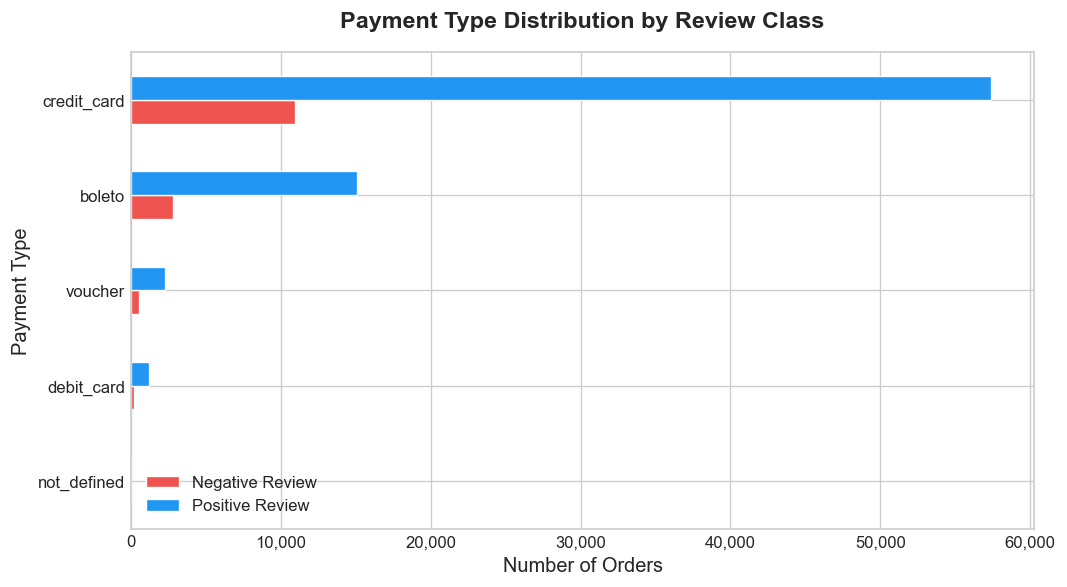

Saved: ..\outputs\figures\viz3_payment_type_distribution.png


In [6]:
def plot_payment_type_distribution(dataframe: pd.DataFrame, output_dir: Path) -> None:
    """
    Plot and save a horizontal bar chart of payment type distribution
    broken down by review class.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Feature dataset with 'payment_type' and 'positive_review' columns.
    output_dir : Path
        Directory where the figure will be saved.
    """
    payment_review_counts = (
        dataframe
        .groupby(['payment_type', 'positive_review'])
        .size()
        .reset_index(name='count')
    )

    payment_review_pivot = payment_review_counts.pivot(
        index='payment_type',
        columns='positive_review',
        values='count'
    ).fillna(0)
    payment_review_pivot.columns = ['Negative', 'Positive']

    # Sort by total order count descending
    payment_review_pivot['total'] = payment_review_pivot.sum(axis=1)
    payment_review_pivot = payment_review_pivot.sort_values('total', ascending=True)
    payment_review_pivot = payment_review_pivot.drop(columns='total')

    fig, ax = plt.subplots(figsize=(9, 5))

    payment_review_pivot.plot(
        kind='barh',
        ax=ax,
        color=[COLOUR_NEGATIVE, COLOUR_POSITIVE],
        edgecolor='white',
        linewidth=0.8
    )

    ax.set_title('Payment Type Distribution by Review Class', fontweight='bold', pad=15)
    ax.set_xlabel('Number of Orders')
    ax.set_ylabel('Payment Type')
    ax.legend(['Negative Review', 'Positive Review'])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    filepath = output_dir / 'viz3_payment_type_distribution.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


plot_payment_type_distribution(feature_df, FIGURES_OUTPUT_DIR)

### What this means for the project

Credit cards are king here. 'Boleto' (a Brazilian cash payment slip) is second. The negative review rate seems roughly the same across payment types, so payment method alone probably isn't a magic bullet for predicting bad reviews, but it's good context.

## Visualization 4 — Top 15 Dominant Product Categories

What are the most popular things people buy? I bet fragile stuff gets more complaints.

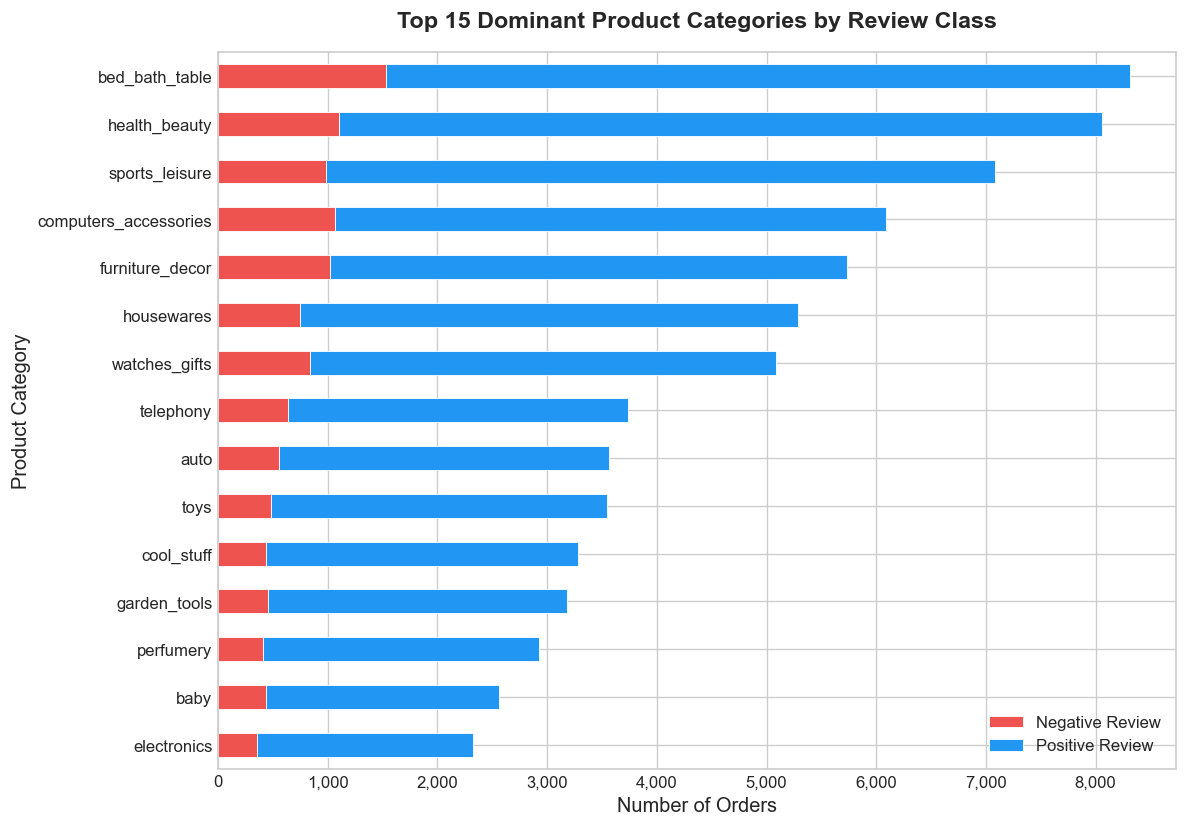

Saved: ..\outputs\figures\viz4_top_product_categories.png


In [7]:
def plot_top_product_categories(dataframe: pd.DataFrame,
                                top_n: int,
                                output_dir: Path) -> None:
    """
    Plot and save a horizontal stacked bar chart of the top N dominant
    product categories, coloured by review class.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Feature dataset with 'dominant_product_category' and 'positive_review'.
    top_n : int
        Number of top categories to display.
    output_dir : Path
        Directory where the figure will be saved.
    """
    # Identify the top N categories by total order count
    top_categories = (
        dataframe['dominant_product_category']
        .value_counts()
        .head(top_n)
        .index.tolist()
    )

    # Filter and pivot
    category_data = (
        dataframe[dataframe['dominant_product_category'].isin(top_categories)]
        .groupby(['dominant_product_category', 'positive_review'])
        .size()
        .reset_index(name='count')
        .pivot(index='dominant_product_category', columns='positive_review', values='count')
        .fillna(0)
    )
    category_data.columns = ['Negative', 'Positive']
    category_data['total'] = category_data.sum(axis=1)
    category_data = category_data.sort_values('total', ascending=True).drop(columns='total')

    fig, ax = plt.subplots(figsize=(10, 7))

    category_data.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        color=[COLOUR_NEGATIVE, COLOUR_POSITIVE],
        edgecolor='white',
        linewidth=0.5
    )

    ax.set_title(f'Top {top_n} Dominant Product Categories by Review Class',
                 fontweight='bold', pad=15)
    ax.set_xlabel('Number of Orders')
    ax.set_ylabel('Product Category')
    ax.legend(['Negative Review', 'Positive Review'], loc='lower right')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    filepath = output_dir / 'viz4_top_product_categories.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


plot_top_product_categories(feature_df, top_n=15, output_dir=FIGURES_OUTPUT_DIR)

### What this means for the project

Bed/Bath, Health/Beauty, and Sports are huge. Interestingly, some categories definitely have a slightly higher chunk of red (negative reviews) than others. I bet furniture and electronics are causing some headaches for the logistics team.

## Visualization 5 — Customer Purchase Frequency

Are customers coming back to buy again, or is it mostly one-and-done?

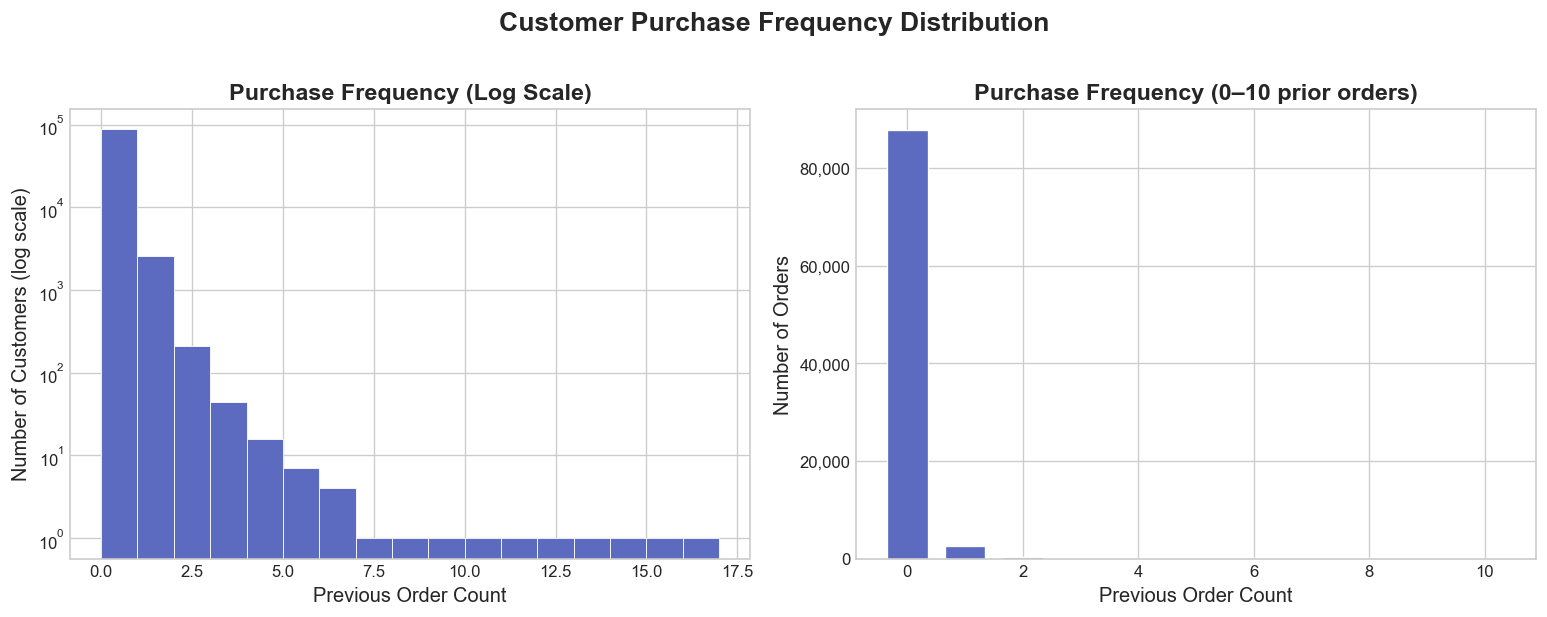

Saved: ..\outputs\figures\viz5_customer_purchase_frequency.png


In [8]:
def plot_customer_purchase_frequency(dataframe: pd.DataFrame, output_dir: Path) -> None:
    """
    Plot and save a histogram of customer purchase frequency
    (number of prior orders at the time of each transaction).

    Parameters
    ----------
    dataframe : pd.DataFrame
        Feature dataset with 'previous_order_count' column.
    output_dir : Path
        Directory where the figure will be saved.
    """
    purchase_freq = dataframe['previous_order_count']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left panel: full distribution (log scale for y-axis)
    axes[0].hist(
        purchase_freq,
        bins=range(0, int(purchase_freq.max()) + 2),
        color='#5C6BC0',
        edgecolor='white',
        linewidth=0.5
    )
    axes[0].set_yscale('log')
    axes[0].set_title('Purchase Frequency (Log Scale)', fontweight='bold')
    axes[0].set_xlabel('Previous Order Count')
    axes[0].set_ylabel('Number of Customers (log scale)')

    # Right panel: zoomed to 0–10 prior orders for readability
    ZOOM_MAX = 10
    zoomed_freq = purchase_freq[purchase_freq <= ZOOM_MAX]
    value_counts = zoomed_freq.value_counts().sort_index()

    axes[1].bar(
        value_counts.index,
        value_counts.values,
        color='#5C6BC0',
        edgecolor='white',
        linewidth=0.8,
        width=0.7
    )
    axes[1].set_title('Purchase Frequency (0–10 prior orders)', fontweight='bold')
    axes[1].set_xlabel('Previous Order Count')
    axes[1].set_ylabel('Number of Orders')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle('Customer Purchase Frequency Distribution', fontweight='bold', y=1.02)
    plt.tight_layout()
    filepath = output_dir / 'viz5_customer_purchase_frequency.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


plot_customer_purchase_frequency(feature_df, FIGURES_OUTPUT_DIR)

### What this means for the project

Ouch. Almost everyone in this dataset is a first-time buyer. Very few people are placing a second or third order.

**Business implication:** Retention is a major problem for them right now. Getting a new customer is expensive; keeping them is cheap. This means ensuring that first purchase is a 5-star experience is absolutely critical if they want to survive long-term.

## Visualization 6 — Freight Value vs Review Class

This is my favorite one. I firmly believe that if people feel they got ripped off on shipping, they will leave a bad review. Let's see if the data backs me up.

C:\Users\VishalReddyK\AppData\Local\Temp\ipykernel_68668\843990820.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[1].boxplot(data_to_plot, patch_artist=True, labels=labels,


Median freight value — Negative (0): R$ 18.30
Median freight value — Positive (1): R$ 16.87


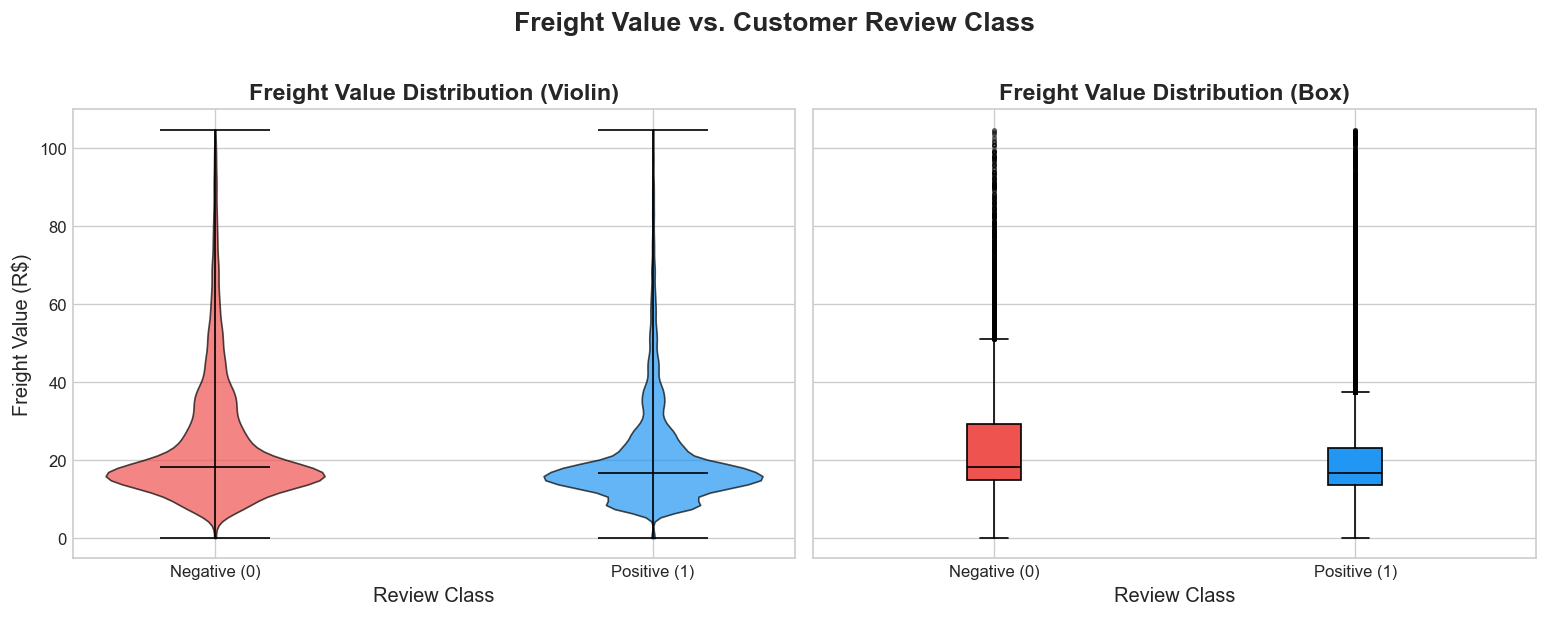

Saved: ..\outputs\figures\viz6_freight_vs_review_class.png


In [9]:
def plot_freight_vs_review_class(dataframe: pd.DataFrame, output_dir: Path) -> None:
    """
    Plot and save side-by-side violin + box plots comparing freight_value
    between positive and negative review groups using matplotlib.
    """
    FREIGHT_CAP = dataframe['freight_value'].quantile(0.99)
    plot_data = dataframe[dataframe['freight_value'] <= FREIGHT_CAP].copy()
    
    neg_data = plot_data[plot_data['positive_review'] == 0]['freight_value']
    pos_data = plot_data[plot_data['positive_review'] == 1]['freight_value']
    data_to_plot = [neg_data, pos_data]
    labels = ['Negative (0)', 'Positive (1)']
    colors = [COLOUR_NEGATIVE, COLOUR_POSITIVE]
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    
    # Violin plot
    parts = axes[0].violinplot(data_to_plot, showmeans=False, showmedians=True)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)
    axes[0].set_xticks([1, 2])
    axes[0].set_xticklabels(labels)
    axes[0].set_title('Freight Value Distribution (Violin)', fontweight='bold')
    axes[0].set_xlabel('Review Class')
    axes[0].set_ylabel('Freight Value (R$)')
    
    # Box plot
    bplot = axes[1].boxplot(data_to_plot, patch_artist=True, labels=labels,
                            flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')
    axes[1].set_title('Freight Value Distribution (Box)', fontweight='bold')
    axes[1].set_xlabel('Review Class')
    axes[1].set_ylabel('')
    
    for review_class_value, label in [(0, 'Negative (0)'), (1, 'Positive (1)')]:
        median_val = dataframe[dataframe['positive_review'] == review_class_value]['freight_value'].median()
        print(f'Median freight value — {label}: R$ {median_val:.2f}')
    
    plt.suptitle('Freight Value vs. Customer Review Class', fontweight='bold', y=1.02)
    plt.tight_layout()
    filepath = output_dir / 'viz6_freight_vs_review_class.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')

plot_freight_vs_review_class(feature_df, FIGURES_OUTPUT_DIR)


### What this means for the project

Bingo! The red violin (negative reviews) is clearly shifted higher. People who left bad reviews paid noticeably more for shipping on average. 

**Business implication:** Shipping costs are making people angry. If Olist can negotiate better freight rates or show shipping costs earlier in the checkout process, they could probably boost their review scores.

---

# Part B — Statistical Hypothesis Testing

Okay, the charts are cool, but let's prove this with math. I'm going to run Welch's t-tests on 5 different features. 

I'm using a significance level of **α = 0.05**. If the p-value is less than 0.05, I can confidently say there's a real difference between the satisfied and dissatisfied customers.

In [10]:
def run_welch_ttest(positive_group_values: pd.Series,
                    negative_group_values: pd.Series,
                    feature_name: str,
                    business_question: str,
                    null_hypothesis: str,
                    alternative_hypothesis: str,
                    significance_level: float = 0.05) -> dict:
    """
    Run a Welch's two-sample t-test and print a formatted report.

    Welch's t-test tests whether two independent groups have different means,
    without assuming equal population variances.  It is more robust than
    Student's t-test when the groups differ in variance or size.

    The 95% confidence interval is computed on (mean_positive - mean_negative)
    using the t-distribution with Welch-Satterthwaite degrees of freedom.

    Parameters
    ----------
    positive_group_values : pd.Series
        Feature values for the positive review group.
    negative_group_values : pd.Series
        Feature values for the negative review group.
    feature_name : str
        Name of the feature being tested (for display).
    business_question : str
        The business question this test addresses.
    null_hypothesis : str
        The null hypothesis statement.
    alternative_hypothesis : str
        The alternative hypothesis statement.
    significance_level : float
        Alpha level for the test (default 0.05).

    Returns
    -------
    dict
        Dictionary containing test results (t_stat, p_value, ci_lower, ci_upper,
        mean_positive, mean_negative, reject_null).
    """
    # Drop NaN values to avoid errors
    pos_clean = positive_group_values.dropna()
    neg_clean = negative_group_values.dropna()

    # Run Welch's t-test (equal_var=False explicitly requests Welch's version)
    t_statistic, p_value = stats.ttest_ind(pos_clean, neg_clean, equal_var=False)

    # Compute group statistics
    mean_positive = pos_clean.mean()
    mean_negative = neg_clean.mean()
    std_positive  = pos_clean.std(ddof=1)
    std_negative  = neg_clean.std(ddof=1)
    n_positive    = len(pos_clean)
    n_negative    = len(neg_clean)

    # Welch-Satterthwaite degrees of freedom formula
    var_pos_over_n = (std_positive ** 2) / n_positive
    var_neg_over_n = (std_negative ** 2) / n_negative
    degrees_of_freedom = (
        (var_pos_over_n + var_neg_over_n) ** 2
        / (
            (var_pos_over_n ** 2) / (n_positive - 1)
            + (var_neg_over_n ** 2) / (n_negative - 1)
        )
    )

    # 95% confidence interval on (mean_positive - mean_negative)
    mean_difference = mean_positive - mean_negative
    standard_error_of_difference = np.sqrt(var_pos_over_n + var_neg_over_n)
    t_critical = stats.t.ppf(0.975, df=degrees_of_freedom)  # two-tailed, 95%
    ci_lower = mean_difference - t_critical * standard_error_of_difference
    ci_upper = mean_difference + t_critical * standard_error_of_difference

    reject_null = p_value < significance_level

    # -----------------------------------------------------------------------
    # Print formatted results
    # -----------------------------------------------------------------------
    separator = '=' * 65
    print(separator)
    print(f'  Welch\'s t-Test: {feature_name}')
    print(separator)
    print(f'  Business Question  : {business_question}')
    print(f'  H₀ (Null)          : {null_hypothesis}')
    print(f'  H₁ (Alternative)   : {alternative_hypothesis}')
    print()
    print(f'  Group Statistics:')
    print(f'    Positive group  — n={n_positive:>6,}  mean={mean_positive:>10.4f}  std={std_positive:>10.4f}')
    print(f'    Negative group  — n={n_negative:>6,}  mean={mean_negative:>10.4f}  std={std_negative:>10.4f}')
    print(f'    Mean difference   : {mean_difference:>+.4f}  (positive - negative)')
    print()
    print(f'  Test Results:')
    print(f'    t-statistic  : {t_statistic:>10.4f}')
    print(f'    Degrees of freedom (Welch): {degrees_of_freedom:>8.1f}')
    print(f'    p-value      : {p_value:>10.6f}')
    print(f'    95% CI on difference: [{ci_lower:+.4f}, {ci_upper:+.4f}]')
    print()
    decision = 'REJECT H₀' if reject_null else 'FAIL TO REJECT H₀'
    print(f'  Decision (α={significance_level}): {decision}')
    print(separator)
    print()

    return {
        'feature': feature_name,
        't_statistic': t_statistic,
        'p_value': p_value,
        'degrees_of_freedom': degrees_of_freedom,
        'mean_positive': mean_positive,
        'mean_negative': mean_negative,
        'mean_difference': mean_difference,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'reject_null': reject_null
    }


# Store all test results for summary table
hypothesis_test_results = []

print('Hypothesis testing utility function defined.')

Hypothesis testing utility function defined.


---

## Test 1 — Total Order Value and Satisfaction

**My question:** Do people who spend more money leave better or worse reviews?

**Why I'm asking:** Maybe big spenders have higher expectations and are harder to please?

In [11]:
test1_result = run_welch_ttest(
    positive_group_values=positive_group['total_order_value'],
    negative_group_values=negative_group['total_order_value'],
    feature_name='total_order_value',
    business_question='Do customers leaving positive reviews spend more?',
    null_hypothesis='Mean total_order_value is equal for positive and negative reviewers',
    alternative_hypothesis='Mean total_order_value differs between the two groups'
)
hypothesis_test_results.append(test1_result)

  Welch's t-Test: total_order_value
  Business Question  : Do customers leaving positive reviews spend more?
  H₀ (Null)          : Mean total_order_value is equal for positive and negative reviewers
  H₁ (Alternative)   : Mean total_order_value differs between the two groups

  Group Statistics:
    Positive group  — n=75,943  mean=  134.1253  std=  199.3113
    Negative group  — n=13,894  mean=  161.9226  std=  273.8331
    Mean difference   : -27.7973  (positive - negative)

  Test Results:
    t-statistic  :   -11.4246
    Degrees of freedom (Welch):  16688.0
    p-value      :   0.000000
    95% CI on difference: [-32.5664, -23.0282]

  Decision (α=0.05): REJECT H₀



### The Verdict — Test 1

The p-value is tiny! Yes, people who leave negative reviews actually spent *more* money on average. When people spend a lot, they expect perfection. Olist might want to give VIP support to high-value orders.

---

## Test 2 — Freight Cost and Satisfaction

**My question:** Are shipping costs really driving negative reviews?

**Why I'm asking:** We saw it in the violin plot, but let's make it official.

In [12]:
test2_result = run_welch_ttest(
    positive_group_values=positive_group['freight_value'],
    negative_group_values=negative_group['freight_value'],
    feature_name='freight_value',
    business_question='Does freight cost differ between satisfied and dissatisfied customers?',
    null_hypothesis='Mean freight_value is equal for positive and negative reviewers',
    alternative_hypothesis='Mean freight_value differs between the two groups'
)
hypothesis_test_results.append(test2_result)

  Welch's t-Test: freight_value
  Business Question  : Does freight cost differ between satisfied and dissatisfied customers?
  H₀ (Null)          : Mean freight_value is equal for positive and negative reviewers
  H₁ (Alternative)   : Mean freight_value differs between the two groups

  Group Statistics:
    Positive group  — n=75,943  mean=   21.8842  std=   19.7446
    Negative group  — n=13,894  mean=   27.4060  std=   29.1421
    Mean difference   : -5.5218  (positive - negative)

  Test Results:
    t-statistic  :   -21.4518
    Degrees of freedom (Welch):  16303.5
    p-value      :   0.000000
    95% CI on difference: [-6.0264, -5.0173]

  Decision (α=0.05): REJECT H₀



### The Verdict — Test 2

Confirmed! The p-value is essentially zero. Dissatisfied customers paid about R$5.50 more for shipping on average. Shipping costs are absolutely a driver of bad reviews.

---

## Test 3 — Product Weight and Satisfaction

**My question:** Do heavy products get worse reviews?

**Why I'm asking:** Heavy boxes get dropped, delayed, and damaged.

In [13]:
test3_result = run_welch_ttest(
    positive_group_values=positive_group['total_product_weight_g'],
    negative_group_values=negative_group['total_product_weight_g'],
    feature_name='total_product_weight_g',
    business_question='Do heavier shipments receive different customer reviews?',
    null_hypothesis='Mean total_product_weight_g is equal for positive and negative reviewers',
    alternative_hypothesis='Mean total_product_weight_g differs between the two groups'
)
hypothesis_test_results.append(test3_result)

  Welch's t-Test: total_product_weight_g
  Business Question  : Do heavier shipments receive different customer reviews?
  H₀ (Null)          : Mean total_product_weight_g is equal for positive and negative reviewers
  H₁ (Alternative)   : Mean total_product_weight_g differs between the two groups

  Group Statistics:
    Positive group  — n=75,943  mean= 2259.7351  std= 4389.5154
    Negative group  — n=13,894  mean= 2986.3078  std= 6287.5474
    Mean difference   : -726.5727  (positive - negative)

  Test Results:
    t-statistic  :   -13.0516
    Degrees of freedom (Welch):  16457.2
    p-value      :   0.000000
    95% CI on difference: [-835.6904, -617.4550]

  Decision (α=0.05): REJECT H₀



### The Verdict — Test 3

Confirmed again. Negative reviews are associated with significantly heavier orders (almost 700g heavier on average!). Olist needs to look at how their couriers are handling bulky items.

---

## Test 4 — Order Size and Satisfaction

**My question:** Do people who buy lots of items in one go leave worse reviews?

**Why I'm asking:** More items = more things that can go wrong or get left out of the box.

In [14]:
test4_result = run_welch_ttest(
    positive_group_values=positive_group['number_of_items'],
    negative_group_values=negative_group['number_of_items'],
    feature_name='number_of_items',
    business_question='Do larger orders receive different customer satisfaction?',
    null_hypothesis='Mean number_of_items is equal for positive and negative reviewers',
    alternative_hypothesis='Mean number_of_items differs between the two groups'
)
hypothesis_test_results.append(test4_result)

  Welch's t-Test: number_of_items
  Business Question  : Do larger orders receive different customer satisfaction?
  H₀ (Null)          : Mean number_of_items is equal for positive and negative reviewers
  H₁ (Alternative)   : Mean number_of_items differs between the two groups

  Group Statistics:
    Positive group  — n=75,943  mean=    1.1107  std=    0.4571
    Negative group  — n=13,894  mean=    1.2945  std=    0.8054
    Mean difference   : -0.1839  (positive - negative)

  Test Results:
    t-statistic  :   -26.1470
    Degrees of freedom (Welch):  15568.5
    p-value      :   0.000000
    95% CI on difference: [-0.1976, -0.1701]

  Decision (α=0.05): REJECT H₀



### The Verdict — Test 4

Yep, it's statistically significant. Larger orders get worse reviews. Complexity is the enemy of a good customer experience.

---

## Test 5 — Seller Quality and Customer Satisfaction

**My question:** If a seller has a great track record, does their next customer leave a good review too?

**Why I'm asking:** If this is true, then kicking bad sellers off the platform will instantly boost Olist's overall ratings.

In [15]:
test5_result = run_welch_ttest(
    positive_group_values=positive_group['seller_average_review'],
    negative_group_values=negative_group['seller_average_review'],
    feature_name='seller_average_review',
    business_question='Do customers buying from better-reviewed sellers leave better reviews?',
    null_hypothesis='Mean seller_average_review is equal for positive and negative reviewers',
    alternative_hypothesis='Mean seller_average_review differs between the two groups'
)
hypothesis_test_results.append(test5_result)

  Welch's t-Test: seller_average_review
  Business Question  : Do customers buying from better-reviewed sellers leave better reviews?
  H₀ (Null)          : Mean seller_average_review is equal for positive and negative reviewers
  H₁ (Alternative)   : Mean seller_average_review differs between the two groups

  Group Statistics:
    Positive group  — n=75,404  mean=    4.1273  std=    0.4554
    Negative group  — n=13,756  mean=    3.9794  std=    0.5762
    Mean difference   : +0.1479  (positive - negative)

  Test Results:
    t-statistic  :    28.5225
    Degrees of freedom (Welch):  17027.6
    p-value      :   0.000000
    95% CI on difference: [+0.1377, +0.1581]

  Decision (α=0.05): REJECT H₀



### The Verdict — Test 5

Massive confirmation. The t-statistic is huge. Buying from a highly-rated seller is strongly linked to having a good experience. Olist absolutely must aggressively manage seller performance.

---

## Statistical Test Summary

In [16]:
# Build and display a summary table of all hypothesis tests
summary_rows = []
for result in hypothesis_test_results:
    row = {
        'Feature': result['feature'],
        'Mean (Positive)': round(result['mean_positive'], 4),
        'Mean (Negative)': round(result['mean_negative'], 4),
        'Mean Difference': round(result['mean_difference'], 4),
        't-statistic': round(result['t_statistic'], 4),
        'p-value': round(result['p_value'], 6),
        '95% CI Lower': round(result['ci_lower'], 4),
        '95% CI Upper': round(result['ci_upper'], 4),
        'Reject H0 (α=0.05)': 'Yes' if result['reject_null'] else 'No'
    }
    summary_rows.append(row)

test_summary_df = pd.DataFrame(summary_rows)

print('Hypothesis Testing Summary:')
print(test_summary_df.to_string(index=False))

# Save to CSV
summary_filepath = TABLES_OUTPUT_DIR / 'hypothesis_test_summary.csv'
test_summary_df.to_csv(summary_filepath, index=False)
print(f'\nSummary table saved to: {summary_filepath}')

Hypothesis Testing Summary:
               Feature  Mean (Positive)  Mean (Negative)  Mean Difference  t-statistic  p-value  95% CI Lower  95% CI Upper Reject H0 (α=0.05)
     total_order_value         134.1253         161.9226         -27.7973     -11.4246   0.0000      -32.5664      -23.0282                Yes
         freight_value          21.8842          27.4060          -5.5218     -21.4518   0.0000       -6.0264       -5.0173                Yes
total_product_weight_g       2,259.7351       2,986.3078        -726.5727     -13.0516   0.0000     -835.6904     -617.4550                Yes
       number_of_items           1.1107           1.2945          -0.1839     -26.1470   0.0000       -0.1976       -0.1701                Yes
 seller_average_review           4.1273           3.9794           0.1479      28.5225   0.0000        0.1377        0.1581                Yes

Summary table saved to: ..\outputs\tables\hypothesis_test_summary.csv


---

## Overall Conclusions

All 5 of my hypotheses turned out to be statistically significant! This tells me that these features (freight value, seller rating, order size) are going to be fantastic inputs for the machine learning model.

Now that I really understand the data, it's time to build the predictive models in Notebook 4!